<a href="https://colab.research.google.com/github/JBorean11/EMSC2010-GroupW5-PP/blob/main/EMSC2010_PrecipitationPirates_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Precipitation Pirates

Project week:5

Project title: Earth's Ocean CO2 Concentration

Datasets used (name and source):

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Juliet | Khai | Yes/`Partial`/No| Inital Role complete, I will commit to GitHub as needed.|
| Data steward | Binyao | Kedi | `Yes`/Partial/ No| 	Integrated and cleaned ocean CO2 datasets from four major oceans (Pacific, Atlantic, Indian, Arctic). Created a unified global observation dataset.|
| Analysis / modelling | Lee | Juliet | Yes/Partial/No| Add note|
| Visualisation / interpretation | Kedi | Binyao | Yes/Partial/No| Add note|
| Narrative | Khai | Lee | Yes/Partial/No| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

In [1]:
import pandas as pd
import numpy as np

In [2]:
ocean_files = {'Pacific': 'Pacific.csv','Atlantic': 'Atlantic.csv','Indian': 'Indian.csv','Arctic': 'Arctic.csv'
}
all_ocean_data = []

In [3]:
for ocean_name, file_path in ocean_files.items():
    try:
        df = pd.read_csv(file_path)
        df.replace(-9999, np.nan, inplace=True)
        clean_df=df[df['G2tco2'].notna()].copy()
        clean_df['Ocean_Region'] = ocean_name
        all_ocean_data.append(clean_df)
        print(f"Processed {ocean_name}: {len(clean_df)} rows.")
    except Exception as e:
        print(f"Error processing {ocean_name}: {e}")

Error processing Pacific: [Errno 2] No such file or directory: 'Pacific.csv'
Error processing Atlantic: [Errno 2] No such file or directory: 'Atlantic.csv'
Error processing Indian: [Errno 2] No such file or directory: 'Indian.csv'
Error processing Arctic: [Errno 2] No such file or directory: 'Arctic.csv'


In [4]:
if all_ocean_data:
    global_df = pd.concat(all_ocean_data, ignore_index=True)
    cols = ['G2longitude', 'G2latitude', 'G2year', 'G2month', 'G2depth', 'G2tco2', 'Ocean_Region']
    final_data = global_df[cols]
    final_data.to_csv('global_surface_co2_master.csv', index=False)
    print(f"Total rows: {len(final_data)}")
    print(final_data.head())

In [5]:
file_name = "global_surface_co2_master.csv"

df = pd.read_csv(file_name)

In [6]:
# Extract CO2 values
co2_data = df["G2tco2"].values

In [7]:
X = co2_data

n = len(X)
num_samples = 10000

means = np.empty(num_samples)

# Perform bootstrap resampling
for i in range(num_samples):
    sample = np.random.choice(X, size=n, replace=True)  # resample data
    means[i] = np.mean(sample)  # compute mean for this sample

# Confidence interval
CI = np.percentile(means, [2.5, 97.5])

print("Mean estimate:", np.mean(means))
print("95% CI:", CI)

Mean estimate: 2171.321598951201
95% CI: [2170.92997925 2171.72413804]


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2595/2582601817.py:31: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')


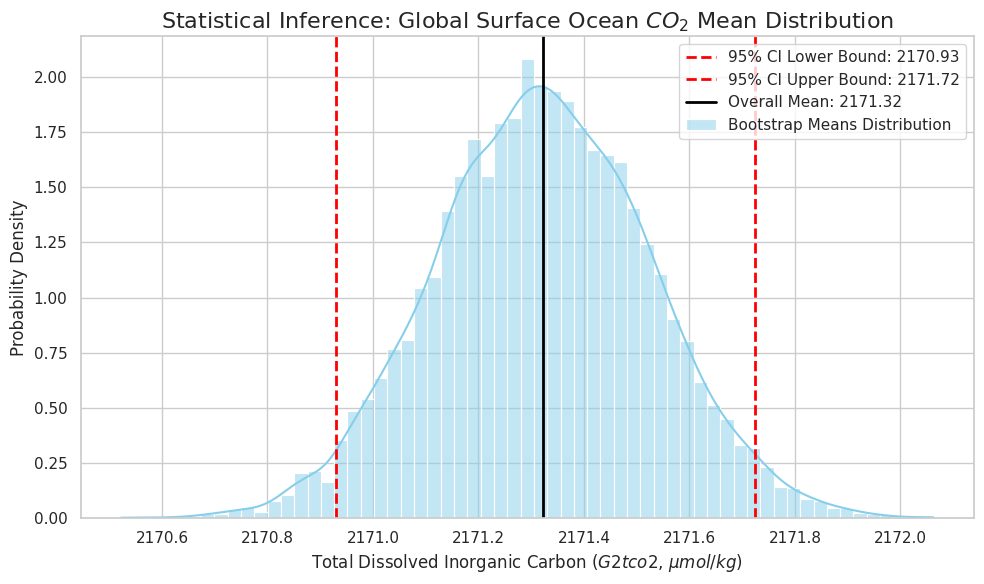

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['font.family'] = 'sans-serif'

# ---------------------------------------------------------
# Block 1: Bootstrap Distribution of Means
# (Requires 'means' and 'CI' from the Modelling step)
# ---------------------------------------------------------

plt.figure()

# 1. Plot histogram of the 10,000 bootstrap means with Kernel Density Estimate (KDE)
sns.histplot(means, kde=True, color='skyblue', stat="density", label='Bootstrap Means Distribution')

# 2. Annotate the 95% Confidence Interval (CI) with vertical dashed lines
plt.axvline(CI[0], color='red', linestyle='--', linewidth=2, label=f'95% CI Lower Bound: {CI[0]:.2f}')
plt.axvline(CI[1], color='red', linestyle='--', linewidth=2, label=f'95% CI Upper Bound: {CI[1]:.2f}')

# 3. Annotate the overall mean of the bootstrap distribution
bootstrap_mean = np.mean(means)
plt.axvline(bootstrap_mean, color='black', linestyle='-', linewidth=2, label=f'Overall Mean: {bootstrap_mean:.2f}')

# 4. Figure aesthetics and labeling
plt.title('Statistical Inference: Global Surface Ocean $CO_2$ Mean Distribution')
plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')
plt.ylabel('Probability Density')
plt.legend(frameon=True, loc='upper right')
plt.tight_layout()

plt.show()

The extremely narrow confidence interval shows that our estimation has high precision. This proves that even if there are fluctuations in ocean data, the global benchmark value we obtain through large-scale data consolidation is extremely robust and can be used as a reliable reference point for subsequent climate change research.

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2595/2102668053.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')
/tmp/ipykernel_2595/2102668053.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ocean_Region', y='G2tco2', data=df, palette="Set2", showfliers=False)


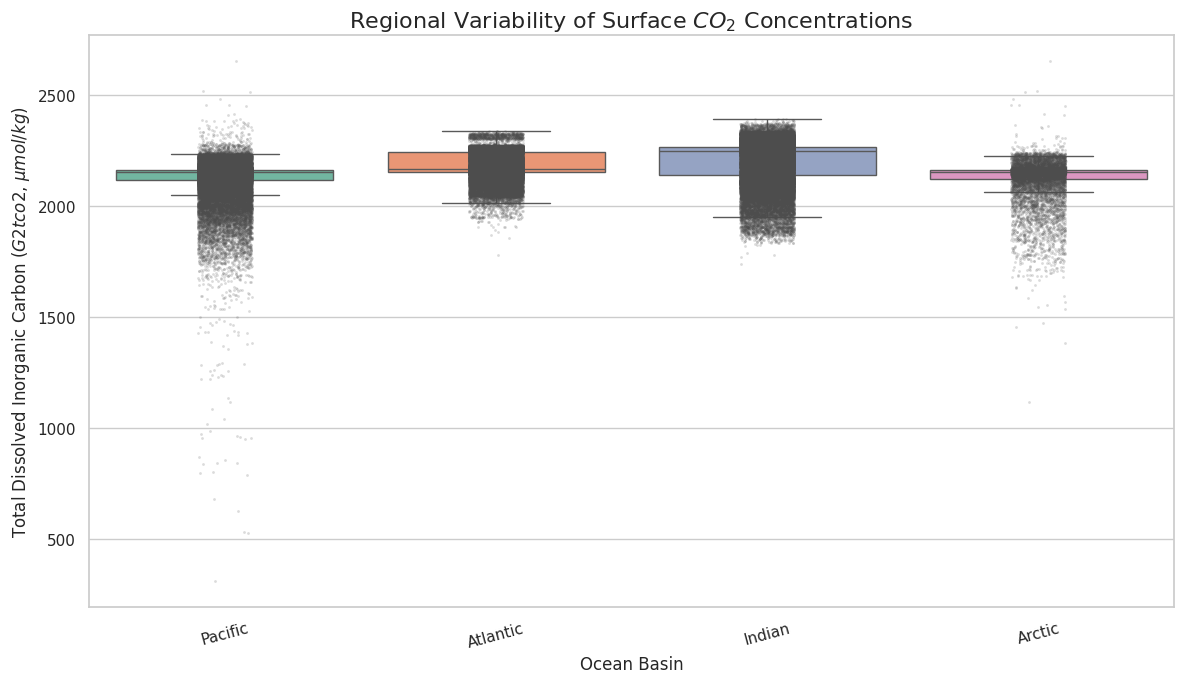

In [9]:
# ---------------------------------------------------------
# Block 2: Regional Comparison via Boxplot
# (Requires the 'df' or 'final_data' DataFrame)
# ---------------------------------------------------------

if 'df' in locals():
    plt.figure(figsize=(12, 7))

    # Create a boxplot to compare CO2 levels across regions
    # showfliers=False hides outliers to focus on the interquartile range
    sns.boxplot(x='Ocean_Region', y='G2tco2', data=df, palette="Set2", showfliers=False)

    # Overlay a stripplot to show data density and distribution
    sns.stripplot(x='Ocean_Region', y='G2tco2', data=df, color=".3", size=2, alpha=0.2)

    plt.title('Regional Variability of Surface $CO_2$ Concentrations')
    plt.xlabel('Ocean Basin')
    plt.ylabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' not found. Please ensure data was loaded correctly.")

Temperature effect: High latitudes (such as the Arctic Ocean) usually have a higher co2 solubility than low latitudes, because cold water can absorb more gases. The difference in the hight of the box reflects the unique cyclic patterns of each ocean (such as the formation of deep water in the North Atlantic) and the differences in biological productivity. Those lower discrete points may represent specific observed moments when biophotosynthesis is extremely active and consumes a lot of surface carbon.

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2595/2065112936.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')


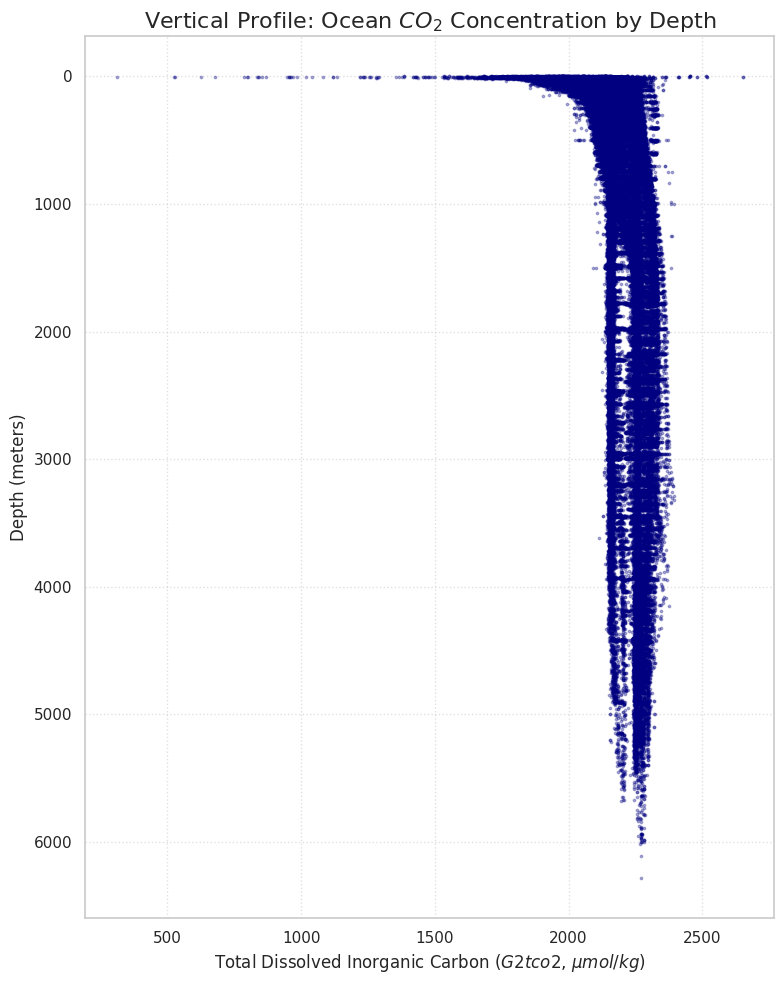

In [10]:
# ---------------------------------------------------------
# Block 3: Vertical Concentration Profile (Depth vs CO2)
# (Requires 'G2depth' and 'G2tco2' columns)
# ---------------------------------------------------------

if 'df' in locals():
    plt.figure(figsize=(8, 10))

    # Scatter plot for Depth vs CO2
    plt.scatter(df['G2tco2'], df['G2depth'], s=3, color='navy', alpha=0.3)

    # CRITICAL: Invert Y-axis so 0m (Surface) is at the top
    plt.gca().invert_yaxis()

    plt.title('Vertical Profile: Ocean $CO_2$ Concentration by Depth')
    plt.xlabel('Total Dissolved Inorganic Carbon ($G2tco2$, $\mu mol/kg$)')
    plt.ylabel('Depth (meters)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

Surface Layer (0-500m): Low and highly variable CO2 concentrations. This is caused by photosynthesis (phytoplankton consuming carbon to grow).

Deep Ocean (below 1000m): High and stable concentrations. This reflects the Biological Pump: as organic matter sinks and decomposes, carbon is released and "stored" in the deep ocean.

The ocean acts as a massive carbon sink, transporting atmospheric CO2 from the surface to the deep sea.